# Plotting

This file is responsible for plotting the results of the models.
The data should be shown in an easy-to-understand manner and all plots should have some guidance
on interpretation and background.

Follow the following guidance:
- Make all assumptions clear.
- Do not hardcode any variables. All must be visible in the sources tab.
- No data computations may be done and only data from ../results may be accessed.

## Downloads

In [17]:
from pathlib import Path
import sys

# Set matlplotlib to inline mode
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [18]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [19]:
# Import the configurations
from configs import PLOTTING_CONFIG
from src.plotting import PLOTTER, tree_plot_portfolios
from src.utils import import_analysis_data

plotter: PLOTTER = PLOTTER(PLOTTING_CONFIG)

In [20]:
# Import files and set index
monthly_factor_loadings, monthly_predicted_returns, factor_loadings_overtime = (
    import_analysis_data()
)

## Data exploration

In [21]:
print(monthly_factor_loadings.T.describe())

            Beta             ...   is_significant                 
           Alpha        CMA  ... ('Tstat', 'RMW') ('Tstat', 'SMB')
count  95.000000  95.000000  ...        95.000000        95.000000
mean   -0.002420   0.063111  ...         0.357895         0.568421
std     0.004853   0.325329  ...         0.481924         0.497924
min    -0.013926  -0.698836  ...         0.000000         0.000000
25%    -0.005142  -0.158676  ...         0.000000         0.000000
50%    -0.001784   0.046070  ...         0.000000         1.000000
75%     0.000971   0.303653  ...         1.000000         1.000000
max     0.011772   1.320277  ...         1.000000         1.000000

[8 rows x 32 columns]


In [22]:
tree_plot_portfolios(
    monthly_predicted_returns.columns.get_level_values(0).unique().to_list()
)

Portfolios
├── Aircraft
│   └── Aircraft - Small Cap
├── Almost Nothing
├── Apparel
│   └── Apparel - Small Cap
├── Automobiles and Trucks
│   ├── Automobiles and Trucks - Small Cap
│   └── Automobiles and Trucks - Large Cap
├── Banking
│   ├── Banking - Small Cap
│   └── Banking - Large Cap
├── Business Services
│   ├── Business Services - Small Cap
│   └── Business Services - Large Cap
├── Chemicals
│   ├── Chemicals - Small Cap
│   └── Chemicals - Large Cap
├── Communication
│   ├── Communication - Small Cap
│   └── Communication - Large Cap
├── Computers
│   ├── Computers - Small Cap
│   └── Computers - Large Cap
├── Construction
│   ├── Construction - Small Cap
│   └── Construction - Large Cap
├── Construction Materials
│   ├── Construction Materials - Small Cap
│   └── Construction Materials - Large Cap
├── Consumer Goods
│   ├── Consumer Goods - Small Cap
│   └── Consumer Goods - Large Cap
├── Electrical Equipment
│   └── Electrical Equipment - Small Cap
├── Electronic Equipment
│   ├── Electronic Equipment - Small Cap
│   └── Electronic Equipment - Large Cap
├── Entertainment
│   └── Entertainment - Small Cap
├── Food Products
│   ├── Food Products - Small Cap
│   └── Food Products - Large Cap
├── Healthcare
│   └── Healthcare - Small Cap
├── Insurance
│   ├── Insurance - Small Cap
│   └── Insurance - Large Cap
├── Machinery
│   ├── Machinery - Small Cap
│   └── Machinery - Large Cap
├── Measuring and Control Equipment
│   ├── Measuring and Control Equipment - Small Cap
│   └── Measuring and Control Equipment - Large Cap
├── Medical Equipment
│   ├── Medical Equipment - Small Cap
│   └── Medical Equipment - Large Cap
├── Non-Metallic and Industrial Metal Mining
│   └── Non-Metallic and Industrial Metal Mining - Small Cap
├── Personal Services
│   ├── Personal Services - Small Cap
│   └── Personal Services - Large Cap
├── Petroleum and Natural Gas
│   ├── Petroleum and Natural Gas - Small Cap
│   └── Petroleum and Natural Gas - Large Cap
├── Pharmaceutical Products
│   ├── Pharmaceutical Products - Small Cap
│   └── Pharmaceutical Products - Large Cap
├── Precious Metals
│   ├── Precious Metals - Small Cap
│   └── Precious Metals - Large Cap
├── Real Estate
│   └── Real Estate - Small Cap
├── Recreation
│   └── Recreation - Small Cap
├── Restaurants, Hotels, Motels
│   ├── Restaurants, Hotels, Motels - Small Cap
│   └── Restaurants, Hotels, Motels - Large Cap
├── Retail
│   ├── Retail - Small Cap
│   └── Retail - Large Cap
├── Steel Works Etc
│   ├── Steel Works Etc - Small Cap
│   └── Steel Works Etc - Large Cap
├── Trading
│   ├── Trading - Small Cap
│   └── Trading - Large Cap
├── Transportation
│   ├── Transportation - Small Cap
│   └── Transportation - Large Cap
├── Utilities
│   ├── Utilities - Small Cap
│   └── Utilities - Large Cap
└── Wholesale
    ├── Wholesale - Small Cap
    └── Wholesale - Large Cap

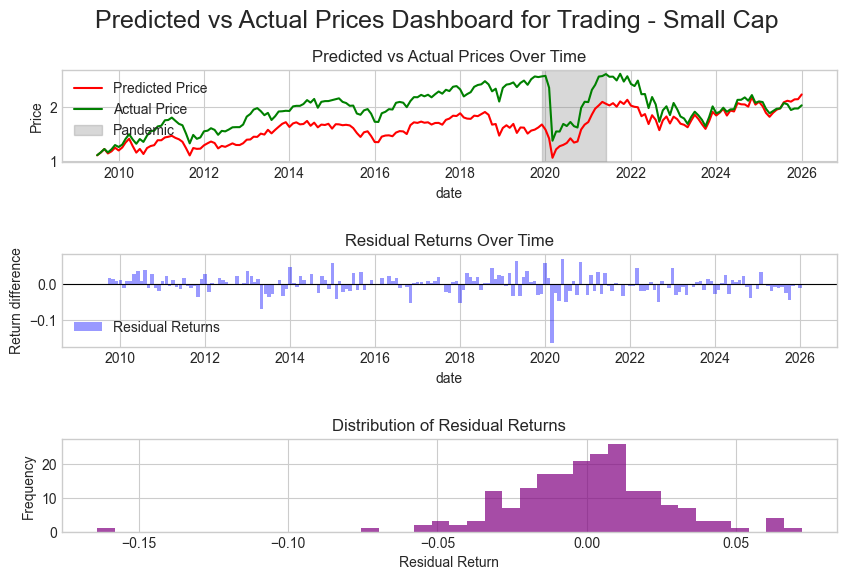

In [23]:
plotter.plot_dashboard_pred_vs_actual_prices(
    monthly_predicted_returns["Trading - Small Cap"],
    asset_name="Trading - Small Cap",
)

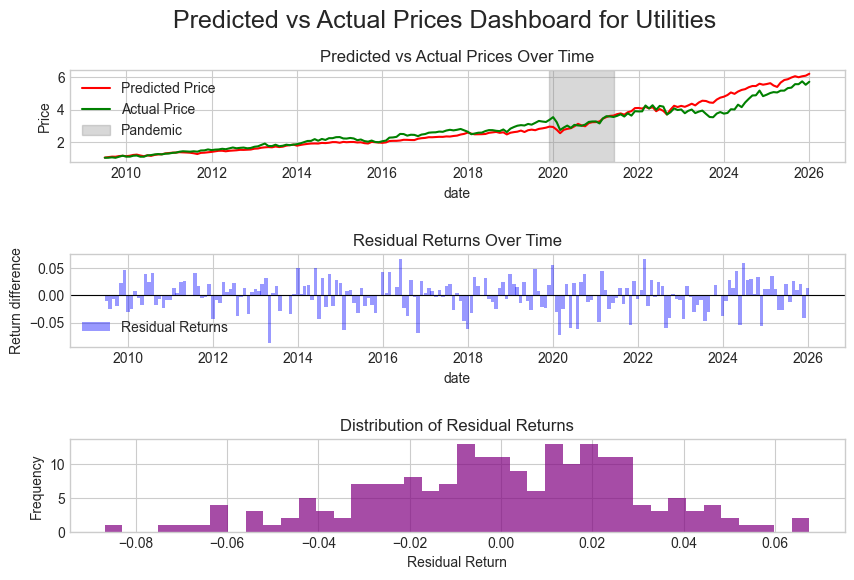

In [24]:
plotter.plot_dashboard_pred_vs_actual_prices(
    monthly_predicted_returns["Utilities"], "Utilities"
)

# Factor loadings entire period

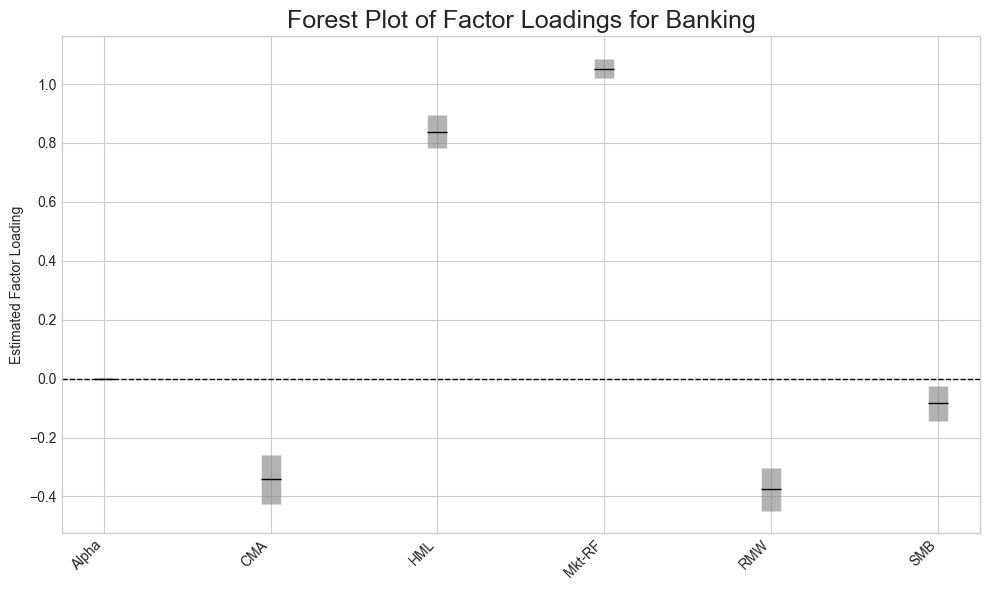

In [25]:
plotter.plot_factor_loadings(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Banking",
    asset_name="Banking",
)

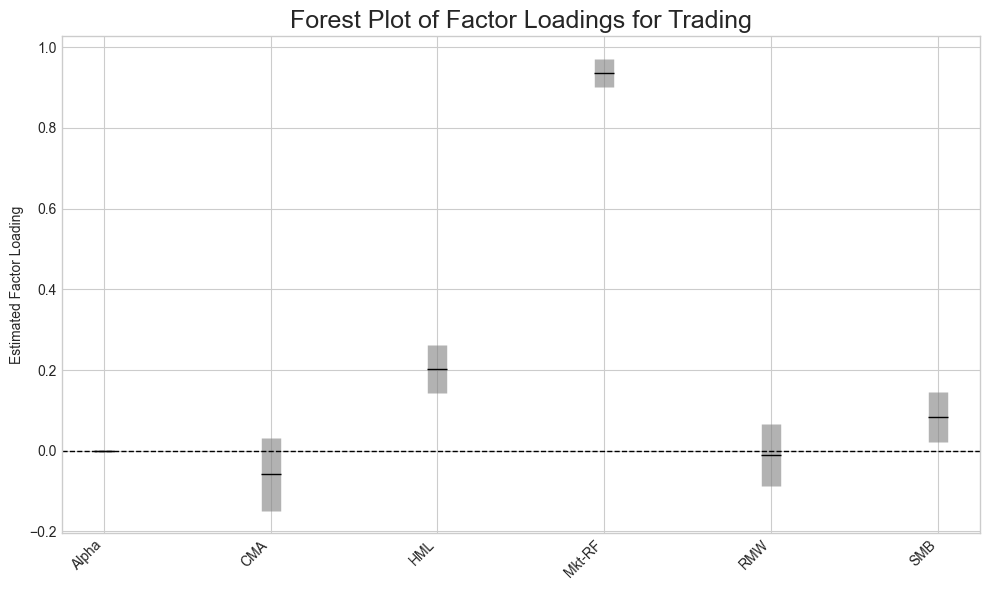

In [26]:
plotter.plot_factor_loadings(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Trading",
    asset_name="Trading",
)

## Factor Loadings Small vs Large cap

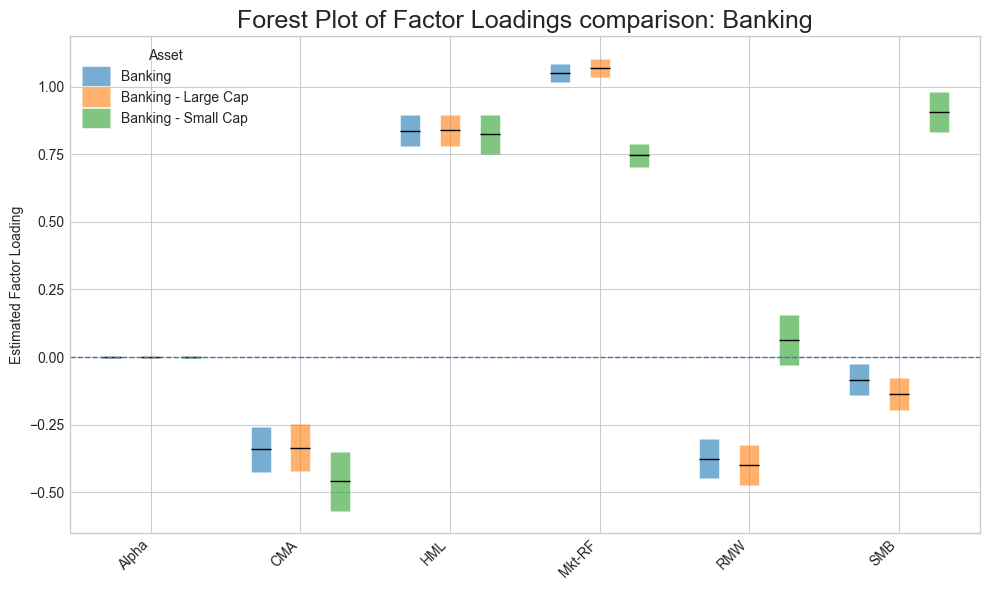

In [27]:
plotter.compare_factor_loadings_small_large(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Banking",
    asset_name="Banking",
)

# Factor loadings over time

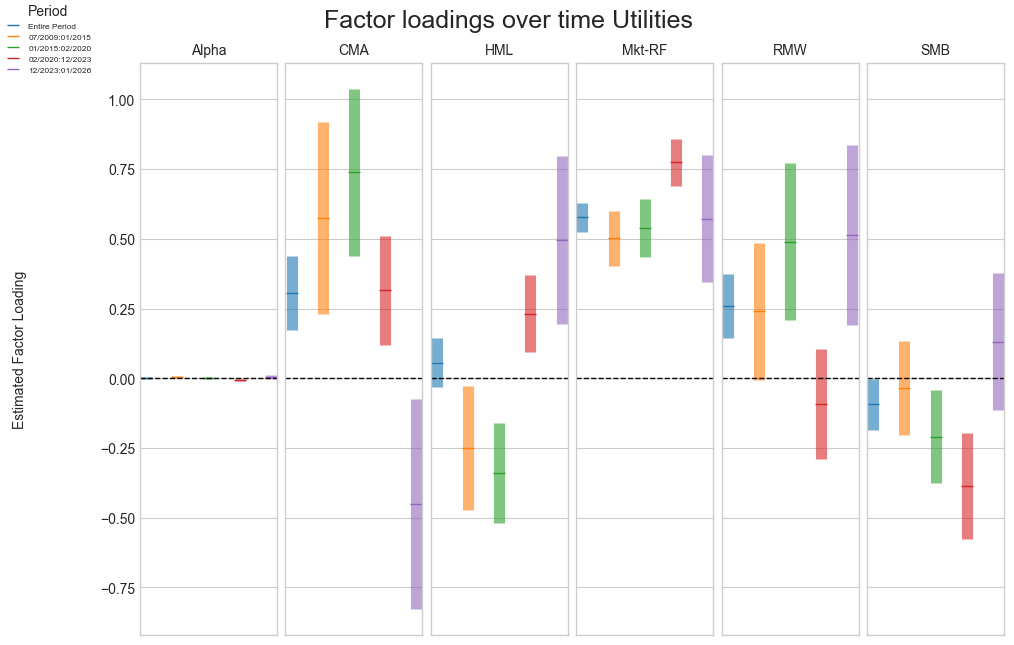

In [28]:
plotter.plot_factor_loadings_over_time(
    factor_loadings_over_time=factor_loadings_overtime,
    asset_identifier="Utilities",
    asset_name="Utilities",
)